# Paris Cultural Events — ML Models
## Model 1: Price Classifier | Model 2: Audience Classifier

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='darkgrid')
print("Libraries loaded.")


Libraries loaded.


## 1. Data Loading & Sampling

In [2]:
df = pd.read_csv('paris_events_for_ml.csv', low_memory=False)
print(f"Full shape: {df.shape}")

# Sample 25k rows for speed — still statistically robust
df = df.sample(n=25000, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Working shape: {df.shape}")
df.head(3)


Full shape: (144969, 16)
Working shape: (25000, 16)


,title,tags,price,booking,is_indoor,pets_allowed,lat,lon,is_paris,zipcode,organiser,venue,sess_day,sess_hour,session_duration,target_audience
0,Découvrez les activités des clubs séniors dans...,Atelier;Loisirs;Solidarité,gratuit,conseillée,1,0,48.834798,2.345398,True,75013,Direction des Solidarités de la Ville de Paris,Club seniors Arago,Sunday,0,23.983333,Adults
1,Paris sport proximité : futsal au centre sport...,Sport,gratuit,non,1,0,48.833071,2.276576,True,75015,Direction de la Jeunesse et des Sports,Centre sportif Suzanne Lenglen,Thursday,0,23.983333,General Public
2,Nan Goldin. This Will Not End Well,Expo;Photo,payant,obligatoire,1,0,48.865912,2.313821,True,75008,Grand Palais,Grand Palais,Tuesday,10,9.500000,General Public


## 2. Cleaning & Target Engineering

In [3]:
# Model 1 target: binary price
df['price_binary'] = df['price'].map({'gratuit':'free','payant':'paid','gratuit sous condition':'paid'})

# Model 2 target: audience (already clean)
df = df.dropna(subset=['price_binary','target_audience','tags','title'])

# Arrondissement from zipcode
df['zipcode'] = df['zipcode'].astype(str).str.strip()
df['arrondissement'] = pd.to_numeric(df['zipcode'], errors='coerce').fillna(0).astype(int) % 100
df.loc[df['arrondissement'] > 20, 'arrondissement'] = 0

# Weekend flag
df['is_weekend'] = df['sess_day'].isin(['Saturday','Sunday']).astype(int)

print("Price distribution:")
print(df['price_binary'].value_counts())
print("\nAudience distribution:")
print(df['target_audience'].value_counts())


Price distribution:
price_binary
free    12830
paid    12170
Name: count, dtype: int64

Audience distribution:
target_audience
Kids & Family     10676
General Public     8447
Adults             5877
Name: count, dtype: int64


## 3. Feature Pipeline Construction

In [4]:
class TagBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self): self.mlb = MultiLabelBinarizer()
    def _split(self, X): return [str(x).split(';') for x in X]
    def fit(self, X, y=None): self.mlb.fit(self._split(X)); return self
    def transform(self, X): return self.mlb.transform(self._split(X)).astype(float)
    def get_feature_names_out(self, _=None): return np.array([f"tag_{c.strip()}" for c in self.mlb.classes_])

DAY_MAP = {d:i for i,d in enumerate(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])}

class DayEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X): return np.array([[DAY_MAP.get(str(v),-1)] for v in X], dtype=float)
    def get_feature_names_out(self, _=None): return np.array(['sess_day_encoded'])

BOOKING_MAP = {'non':0,'conseillée':1,'obligatoire':2}

class BookingEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X): return np.array([[BOOKING_MAP.get(str(v).strip(),0)] for v in X], dtype=float)
    def get_feature_names_out(self, _=None): return np.array(['booking_encoded'])

class NumericCleaner(BaseEstimator, TransformerMixin):
    """Coerce to float and replace non-finite values with 0."""
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = np.array(X, dtype=float)
        return np.where(np.isfinite(X), X, 0.0)
    def get_feature_names_out(self, input_features=None):
        return np.array(input_features) if input_features is not None else np.array([])

NUMERIC_COLS  = ['sess_hour','session_duration','arrondissement','lat','lon','is_weekend']
BINARY_COLS   = ['is_indoor','pets_allowed','is_paris']
TEXT_COL      = 'title'
TAGS_COL      = 'tags'
DAY_COL       = 'sess_day'
BOOKING_COL   = 'booking'
FEATURE_COLS  = NUMERIC_COLS + BINARY_COLS + [TEXT_COL, TAGS_COL, DAY_COL, BOOKING_COL]

def make_preprocessor():
    return ColumnTransformer([
        ('num',     NumericCleaner(),                              NUMERIC_COLS),
        ('binary',  'passthrough',                                 BINARY_COLS),
        ('tfidf',   TfidfVectorizer(max_features=50, sublinear_tf=True), TEXT_COL),
        ('tags',    TagBinarizer(),                                TAGS_COL),
        ('day',     DayEncoder(),                                  DAY_COL),
        ('booking', BookingEncoder(),                              BOOKING_COL),
    ], remainder='drop')

print("Preprocessor ready.")


Preprocessor ready.


## 4. Model 1 — Price Classifier (Random Forest)

In [5]:
X1 = df[FEATURE_COLS].copy()
y1 = df['price_binary'].copy()
for c in BINARY_COLS: X1[c] = X1[c].astype(int)

X1_tr, X1_te, y1_tr, y1_te = train_test_split(X1, y1, test_size=0.2, stratify=y1, random_state=RANDOM_STATE)
print(f"Train: {X1_tr.shape} | Test: {X1_te.shape}")


Train: (20000, 13) | Test: (5000, 13)


In [6]:
pipe1 = Pipeline([
    ('prep',   make_preprocessor()),
    ('select', SelectKBest(f_classif, k=60)),
    ('clf',    RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                      random_state=RANDOM_STATE, n_jobs=-1))
])

# 3-fold CV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv1 = cross_val_score(pipe1, X1_tr, y1_tr, cv=cv, scoring='f1_weighted', n_jobs=-1)
print(f"CV F1: {cv1.mean():.4f} +/- {cv1.std():.4f}")


CV F1: 0.9966 +/- 0.0003


In [7]:
# Quick grid search — 2x2 = 4 fits only
gs1 = GridSearchCV(pipe1, {'clf__max_depth':[20,None],'clf__min_samples_leaf':[1,3]},
                   cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
gs1.fit(X1_tr, y1_tr)
model1 = gs1.best_estimator_
print("Best:", gs1.best_params_, "| F1:", round(gs1.best_score_,4))


Fitting 3 folds for each of 4 candidates, totalling 12 fits


Best: {'clf__max_depth': None, 'clf__min_samples_leaf': 1} | F1: 0.9967


              precision    recall  f1-score   support

        free       1.00      1.00      1.00      2566
        paid       1.00      1.00      1.00      2434

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



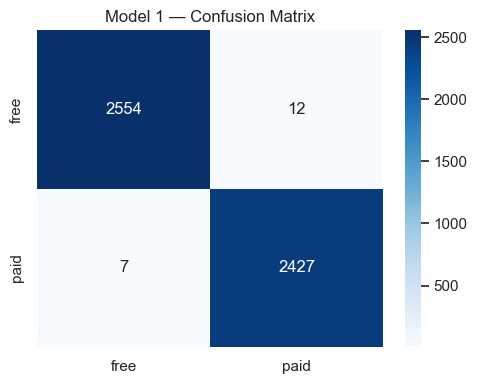

In [8]:
y1_pred = model1.predict(X1_te)
print(classification_report(y1_te, y1_pred))

fig, ax = plt.subplots(figsize=(5,4))
cm = confusion_matrix(y1_te, y1_pred, labels=model1.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model1.classes_, yticklabels=model1.classes_, ax=ax)
ax.set_title('Model 1 — Confusion Matrix'); plt.tight_layout(); plt.show()


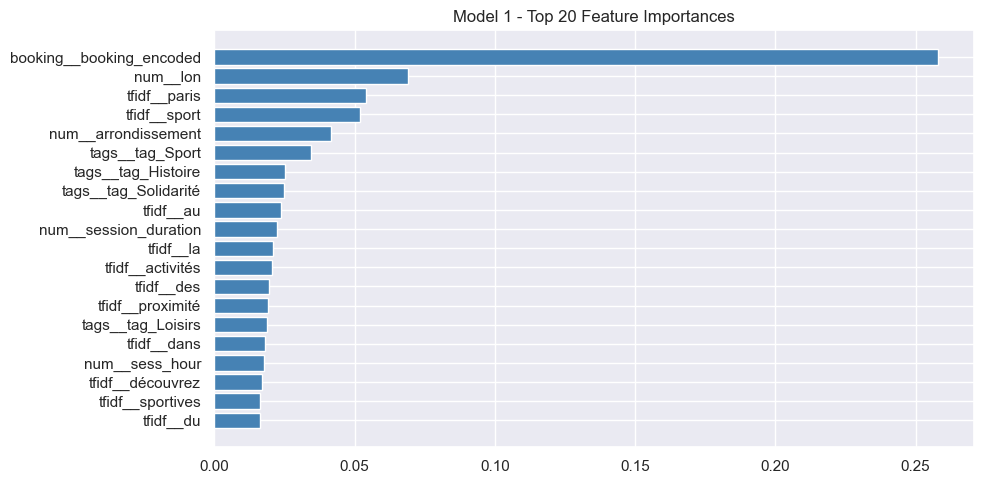

In [9]:
# Feature importance — use ColumnTransformer's built-in name getter
prep1 = model1.named_steps['prep']
sel1  = model1.named_steps['select']
clf1  = model1.named_steps['clf']

all_names  = np.array(prep1.get_feature_names_out())
sel_mask   = sel1.get_support()
sel_names  = all_names[sel_mask]

imp  = clf1.feature_importances_
top  = np.argsort(imp)[-20:][::-1]

fig, ax = plt.subplots(figsize=(10,5))
ax.barh(sel_names[top][::-1], imp[top][::-1], color='steelblue')
ax.set_title('Model 1 - Top 20 Feature Importances'); plt.tight_layout(); plt.show()


## 5. Model 2 — Audience Classifier (Logistic Regression)

In [10]:
X2 = df[FEATURE_COLS].copy()
y2 = df['target_audience'].copy()
for c in BINARY_COLS: X2[c] = X2[c].astype(int)

X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, stratify=y2, random_state=RANDOM_STATE)
print(f"Train: {X2_tr.shape} | Test: {X2_te.shape}")


Train: (20000, 13) | Test: (5000, 13)


In [11]:
pipe2 = Pipeline([
    ('prep',   make_preprocessor()),
    ('select', SelectKBest(f_classif, k=60)),
    ('clf',    LogisticRegression(max_iter=500, class_weight='balanced',
                                   random_state=RANDOM_STATE, solver='lbfgs', n_jobs=-1))
])

cv2 = cross_val_score(pipe2, X2_tr, y2_tr, cv=cv, scoring='f1_weighted', n_jobs=-1)
print(f"CV F1: {cv2.mean():.4f} +/- {cv2.std():.4f}")


CV F1: 0.8270 +/- 0.0024


In [12]:
gs2 = GridSearchCV(pipe2, {'clf__C':[0.1,1.0,10.0]},
                   cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
gs2.fit(X2_tr, y2_tr)
model2 = gs2.best_estimator_
print("Best:", gs2.best_params_, "| F1:", round(gs2.best_score_,4))


Fitting 3 folds for each of 3 candidates, totalling 9 fits


Best: {'clf__C': 10.0} | F1: 0.8324


                precision    recall  f1-score   support

        Adults       0.75      0.89      0.82      1176
General Public       0.86      0.84      0.85      1689
 Kids & Family       0.86      0.79      0.82      2135

      accuracy                           0.83      5000
     macro avg       0.83      0.84      0.83      5000
  weighted avg       0.84      0.83      0.83      5000



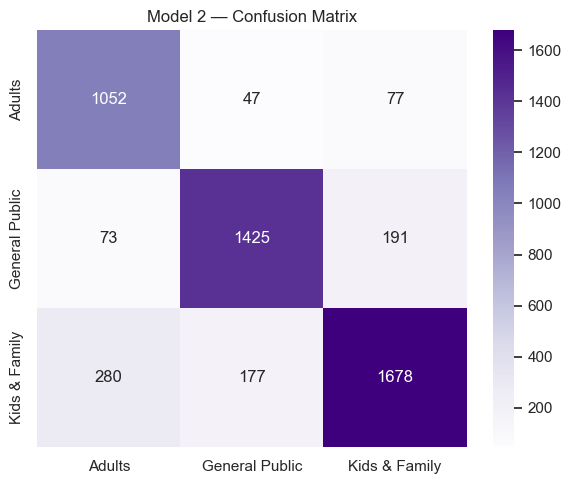

In [13]:
y2_pred = model2.predict(X2_te)
print(classification_report(y2_te, y2_pred))

fig, ax = plt.subplots(figsize=(6,5))
cm2 = confusion_matrix(y2_te, y2_pred, labels=model2.classes_)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Purples',
            xticklabels=model2.classes_, yticklabels=model2.classes_, ax=ax)
ax.set_title('Model 2 — Confusion Matrix'); plt.tight_layout(); plt.show()


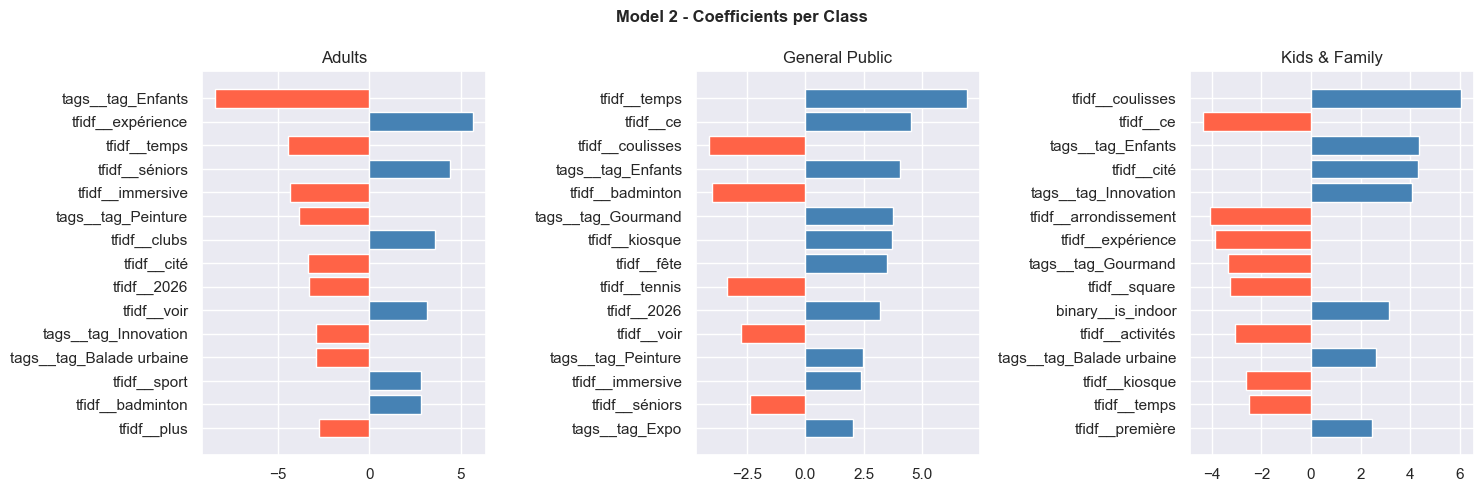

In [14]:
# Coefficient importance per class
prep2 = model2.named_steps['prep']; sel2 = model2.named_steps['select']; clf2 = model2.named_steps['clf']
all_names2 = np.array(prep2.get_feature_names_out())
sel_mask2  = sel2.get_support()
sn2        = all_names2[sel_mask2]

n = len(clf2.classes_)
fig, axes = plt.subplots(1, n, figsize=(5*n,5))
for i,(cls,ax) in enumerate(zip(clf2.classes_, axes)):
    coefs = clf2.coef_[i]; top = np.argsort(np.abs(coefs))[-15:][::-1]
    colors = ['tomato' if coefs[j]<0 else 'steelblue' for j in top]
    ax.barh(sn2[top][::-1], coefs[top][::-1], color=colors[::-1])
    ax.set_title(f'{cls}')
fig.suptitle('Model 2 - Coefficients per Class', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## 6. Model Export

In [15]:
joblib.dump(model1, 'model1_price_classifier.pkl')
joblib.dump(model2, 'model2_audience_classifier.pkl')
print("Saved: model1_price_classifier.pkl")
print("Saved: model2_audience_classifier.pkl")


Saved: model1_price_classifier.pkl
Saved: model2_audience_classifier.pkl


## 7. Web App Integration Functions

In [16]:
# Input schema — pass a dict with these keys:
# {
#   'title':            str,
#   'tags':             str,   # semicolon-separated e.g. 'Concert;Festival'
#   'booking':          str,   # 'non' | 'conseillee' | 'obligatoire'
#   'is_indoor':        int,   # 1 or 0
#   'pets_allowed':     int,   # 1 or 0
#   'lat':              float,
#   'lon':              float,
#   'is_paris':         bool,
#   'zipcode':          str,   # e.g. '75011'
#   'sess_day':         str,   # 'Monday' ... 'Sunday'
#   'sess_hour':        int,   # 0-23
#   'session_duration': float, # hours
# }

_M1 = joblib.load('model1_price_classifier.pkl')
_M2 = joblib.load('model2_audience_classifier.pkl')

def _to_row(event: dict) -> pd.DataFrame:
    row = {c: event.get(c, None) for c in FEATURE_COLS}
    try:   row['arrondissement'] = int(str(row.get('zipcode','75000'))) % 100
    except: row['arrondissement'] = 0
    if row['arrondissement'] > 20: row['arrondissement'] = 0
    row['is_weekend'] = 1 if str(row.get('sess_day','')).strip() in ['Saturday','Sunday'] else 0
    for c in BINARY_COLS: row[c] = int(bool(row.get(c, 0)))
    return pd.DataFrame([row])

def predict_price_type(event: dict) -> dict:
    X = _to_row(event)
    label = _M1.predict(X[FEATURE_COLS])[0]
    conf  = float(_M1.predict_proba(X[FEATURE_COLS])[0].max())
    return {'label': label, 'confidence': round(conf, 4)}

def predict_audience(event: dict) -> dict:
    X = _to_row(event)
    label = _M2.predict(X[FEATURE_COLS])[0]
    conf  = float(_M2.predict_proba(X[FEATURE_COLS])[0].max())
    return {'label': label, 'confidence': round(conf, 4)}

print("predict_price_type() and predict_audience() ready.")


predict_price_type() and predict_audience() ready.


In [17]:
# --- Example Usage ---
example = {
    'title':            'Atelier Peinture pour Enfants',
    'tags':             'Enfants;Loisirs;Atelier',
    'booking':          'obligatoire',
    'is_indoor':        1,
    'pets_allowed':     0,
    'lat':              48.8566,
    'lon':              2.3522,
    'is_paris':         True,
    'zipcode':          '75004',
    'sess_day':         'Saturday',
    'sess_hour':        14,
    'session_duration': 2.0,
}

r1 = predict_price_type(example)
r2 = predict_audience(example)
print(f"Price    -> {r1['label']}  (confidence: {r1['confidence']:.2%})")
print(f"Audience -> {r2['label']}  (confidence: {r2['confidence']:.2%})")


Price    -> free  (confidence: 50.00%)
Audience -> General Public  (confidence: 79.88%)
